## 2. Recreating IMSIP6 total BMB melting

This note book recreates the basal melting figure as submitted in the official paper (credit to Helene Seroussi). Additionally we load a table and group the result by average melting in 2100, 2200 and 2300 and and melt parameterization.

In [74]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n

import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalars'
A =361*10**6 *(1000)**2;
GT_to_mSLE =10**12/(1000 *A)
# GT_to_mSLE = 1/361.8

pth_volume = '/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/'

In [75]:
df = pd.read_csv('metadata.txt')
df['melt2100'] = 0
df['melt2200'] = 0
df['melt2300'] = 0
df

,Unnamed: 0,Climate Forcing,Experiment,GL melt,GL treatment,Group,Main submission,Melt parameterisation,Melt parameters,Model,Model setup,Resolution,Resolution GL,fileID,melt2100,melt2200,melt2300
0,0,ctrl,ctrlAE,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
1,1,CCSM4,expAE02,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
2,2,HadGEM2,expAE03,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
3,3,CESM2,expAE04,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
4,4,UKESM,expAE05,Sub-Grid,Sub-Grid,DC,1.0,Quad. Non-local,AntMean median,ISSM,DC\_ISSM,4km,4km,DC_ISSM,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,ctrl,ctrlAE,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
211,211,CCSM4,expAE02,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
212,212,HadGEM2,expAE03,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0
213,213,CESM2,expAE04,Sub-Grid,Yes,VUW,0.0,Lin,custom,PISM,VUW\_PISM2\_s4,8km,4km,VUW_PISM2_s4,0,0,0


In [76]:
variable2 = 'dslc_anom'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path

pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/'

In [77]:
import matplotlib.ticker as ticker

/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE02/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE02.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE03/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE03.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE04/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE04.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE05/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE05.nc


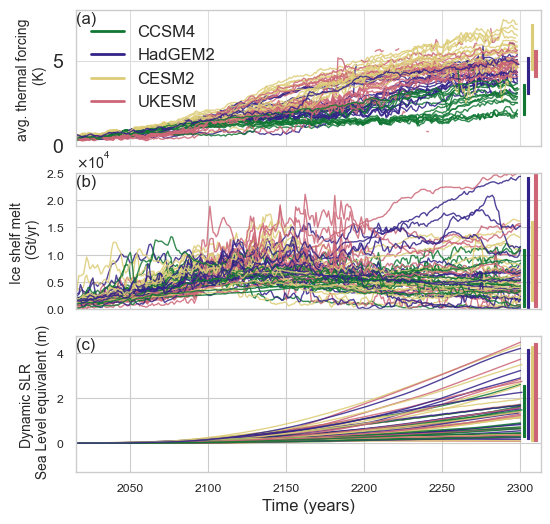

In [78]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

variable3 = 'thermalforcing'

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict = {expname: [] for expname in expnames}
valuesend_dict2 = {expname: [] for expname in expnames}
valuesend_dict3 = {expname: [] for expname in expnames}


dic_all = {}

# colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])
# colors = ['#1f77b4',
#     '#2ca02c',
#     '#9467bd',
#     '#e377c2']
colors = ['#117733', '#332288', '#DDCC77', '#CC6677']
f,ax2 = plt.subplots(3,1, figsize = (6,6),sharex =True)

# --- interlacing fix (Reviewer 1, line 34): collect each line's (color, x, y) here
# instead of plotting immediately, so draw order can be shuffled across ALL models
# and experiments once collection is done, rather than being grouped by color/experiment
lines_forcing = []   # panel (a): thermal forcing
lines_melt = []      # panel (b): ice shelf melt
lines_dslr = []      # panel (c): dynamic SLR


# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
    
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        dataname = file_exp[ifile]
        n1,n2 = dataname.split('shelfmelt')
        dataname =n1 +variable2 +n2
        dataname3 =n1 +variable3 +n2
        
        filename2 =f'{pth_imip6hack}/{expname}/{variable2}/{dataname}'
        filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        malis ='DOE_MALI_4km'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_Ant95'
        if malis in file_exp[ifile]:
            filename3=filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_AntMean'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
            print(filename3)
#         if 'DOE_MALI_4km' in file_exp[ifile];
#             filename3.replace('DOE_MALI_4km' ,renamer['DOE_MALI_4km'] )
#             'DOE_MALI_8km_Ant95'
            
#         filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        

        if "IMAU" in file_exp[ifile]:
#             print(file_exp[ifile])
            file_exp[ifile].replace('computed_shelfmelt_AIS','jb_computed_shelfmelt_AIS')
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        
            
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
       
        d2 = xr.open_dataset(filename2,decode_times=False ) #already GT/yr
        
        data2 = d2.dslc_anom.values *GT_to_mSLE
        
        d3 = xr.open_dataset(filename3,decode_times=False ) #K
        
        data3 = d3.thermalforcing.values
        
        
        
        
#         time = d.time
      

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict[expname].append(-data[time.size-1])
                    lines_melt.append((colors[iexp], d.time.values, -(data[:d.time.size])))
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
                
            if len(data2) > 250:

                if data2[-1] > 0:
                    data2 = -data2

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict2[expname].append(-data2[time.size-1])
                    lines_dslr.append((colors[iexp], d2.time.values, -(data2[:d2.time.size])))
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
            if len(data3) > 250:

                valuesend_dict3[expname].append(data3[time.size-3])
                lines_forcing.append((colors[iexp], d2.time.values[:d3.time.size-2], data3[:d3.time.size-2]))
                    
            else:
                print("experiment too short for")
                
                
                
                
        dic_all[expname]=dic_climateforcing
        

# now that every model/experiment's line has been collected, shuffle the draw order
# within each panel (fixed seed -> reproducible figure) and plot -- this ensures no
# single color is systematically drawn last (and thus visually on top of everything)
rng = np.random.default_rng(0)
for panel_ax, lines in zip([ax2[0], ax2[1], ax2[2]], [lines_forcing, lines_melt, lines_dslr]):
    shuffled = lines.copy()
    rng.shuffle(shuffled)
    for color, x, y in shuffled:
        panel_ax.plot(x, y, linewidth=1, color=color, alpha=0.85)


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict[expname]), np.max(valuesend_dict[expname]),
         np.max(valuesend_dict[expname]), np.min(valuesend_dict[expname])]
    ax2[1].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict2[expname]), np.max(valuesend_dict2[expname]),
         np.max(valuesend_dict2[expname]), np.min(valuesend_dict2[expname])]
    ax2[2].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.nanmin(valuesend_dict3[expname]), np.nanmax(valuesend_dict3[expname]),
         np.nanmax(valuesend_dict3[expname]), np.nanmin(valuesend_dict3[expname])]
    ax2[0].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])

ax2[0].set_ylim([0,8])
ax2[1].set_ylim([0, 2.5 * 10**4])
ax2[2].set_xlabel('Time (years)', fontsize=12)
ax2[1].set_ylabel('Ice shelf melt \n (Gt/yr)', fontsize=10)
# ax = ax2[1]

ax2[2].set_ylabel('Dynamic SLR \n Sea Level equivalent (m)', fontsize=10)


ax2[0].set_ylabel('avg. thermal forcing \n (K)', fontsize=10)



legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax2[0].legend(handles=legend_lines, loc='upper left', fontsize=12, frameon = False)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax2[1].set_xlim([2015, 2313])
ax2[2].set_xlim([2015, 2313])

# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax = ax2[0]  # matches original behaviour (last-set ax inside the old loop was panel a)
ax.tick_params(labelsize=14)
ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
panels = ['(a)','(b)','(c)']
for i in range(3):
    ax = ax2[i]
    ax.text(0.0,0.9,panels[i],transform=ax.transAxes, fontsize=12 )
    ax.set_axisbelow(True)  # keep gridlines behind the range bars / plotted lines
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))  # Always show scientific notation
    ax.yaxis.offsetText.set_fontsize(10)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()
# f.tight_layout()
f.savefig('analysis/figs/paper/Intropic.jpeg')
f.savefig('analysis/figs/paper/Intropic.pdf')

/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE02/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE02.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE03/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE03.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE04/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE04.nc
/Volumes/CrucialX8/computing/data/antarctica/ismip6_hackathon/ComputedScalars//expAE05/thermalforcing/computed_thermalforcing_AIS_DOE_MALI_3_expAE05.nc


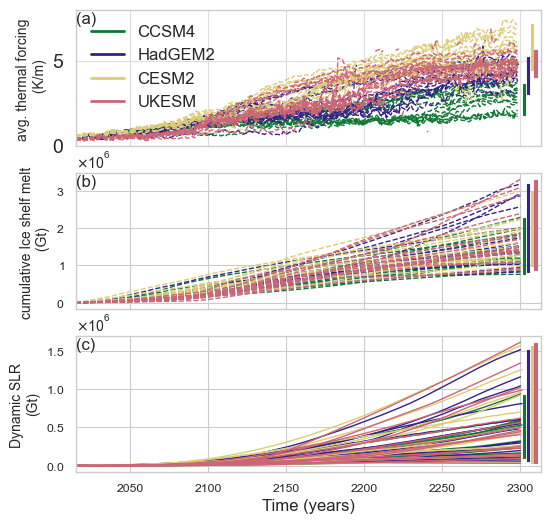

In [79]:
time = np.arange(2016, 2301)
i_2100= np.argwhere(time == 2091)[0][0]
i_2200= np.argwhere(time == 2191)[0][0]
i_2300= np.argwhere(time == 2291)[0][0]

renamer = {}
renamer['DOE_MALI_4km']='DOE_MALI_1'
renamer['DOE_MALI_8km_Ant95']='DOE_MALI_2'
renamer['DOE_MALI_8km_AntMean']='DOE_MALI_3'  

variable3 = 'thermalforcing'

expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
expnames_plot = ['CCSM4','HadGEM2','CESM2','UKESM']

# Create a dictionary to store the lists
valuesend_dict_cum = {expname: [] for expname in expnames}
valuesend_dict2_raw = {expname: [] for expname in expnames}
valuesend_dict3_v2 = {expname: [] for expname in expnames}


dic_all_cum = {}

# colors = np.array([[0, 0.4470, 0.7410], [0.8500, 0.3250, 0.0980], [0.9290, 0.6940, 0.1250], [0.4660, 0.6740, 0.1880]])
# colors = ['#1f77b4',
#     '#2ca02c',
#     '#9467bd',
#     '#e377c2']
colors = ['#117733', '#332288', '#DDCC77', '#CC6677']
f_cum,ax2_cum = plt.subplots(3,1, figsize = (6,6),sharex =True)

# Go over computed scalars and cleanup file names
for iexp, expname in enumerate(expnames):
    dic_climateforcing = {}
    file_exp = os.listdir(f"{computed_name}/{expname}/shelfmelt")
    file_exp = [file for file in file_exp if len(file) >= 3]
    
    for ifile in reversed(range(len(file_exp))):
        if len(file_exp[ifile]) < 3:
            del file_exp[ifile]

    for ifile in range(len(file_exp)):
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        dataname = file_exp[ifile]
        n1,n2 = dataname.split('shelfmelt')
        dataname =n1 +variable2 +n2
        dataname3 =n1 +variable3 +n2
        
        filename2 =f'{pth_imip6hack}/{expname}/{variable2}/{dataname}'
        filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        malis ='DOE_MALI_4km'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_Ant95'
        if malis in file_exp[ifile]:
            filename3=filename3.replace(malis ,renamer[malis] )
        malis = 'DOE_MALI_8km_AntMean'
        if malis in file_exp[ifile]:
            filename3 =filename3.replace(malis ,renamer[malis] )
            print(filename3)
#         if 'DOE_MALI_4km' in file_exp[ifile];
#             filename3.replace('DOE_MALI_4km' ,renamer['DOE_MALI_4km'] )
#             'DOE_MALI_8km_Ant95'
            
#         filename3 =f'{pth_imip6hack}/{expname}/{variable3}/{dataname3}'
        

        if "IMAU" in file_exp[ifile]:
#             print(file_exp[ifile])
            file_exp[ifile].replace('computed_shelfmelt_AIS','jb_computed_shelfmelt_AIS')
        filename = f"{computed_name}/{expname}/shelfmelt/{file_exp[ifile]}"
        
        
            
        d = xr.open_dataset(filename,decode_times=False )
        data = d.shelfmelt.values * 365.25 * 24 * 3600 / 10**12
        
       
        d2 = xr.open_dataset(filename2,decode_times=False ) #already GT/yr
        
        data2 = d2.dslc_anom.values
        
        d3 = xr.open_dataset(filename3,decode_times=False ) #K
        
        data3 = d3.thermalforcing.values
        
        
        
        
#         time = d.time
      

     

        if ("NORCE" in file_exp[ifile] and "NORCE_CISM3-MAR364-ERA-t1-non" not in file_exp[ifile]) or \
           ("VUW" in file_exp[ifile] and "VUW_PISM1_e" not in file_exp[ifile]) or \
           ("DOE" in file_exp[ifile] and "DOE_MALI_4km" not in file_exp[ifile]) or \
           ("NCAR" in file_exp[ifile] and "NCAR_CISM2" not in file_exp[ifile]) or \
           ("LSCE" in file_exp[ifile] and "LSCE_GRISLI_e" not in file_exp[ifile]) or \
           ("ULB" in file_exp[ifile] and "ULB_fETISh-KoriBU1" not in file_exp[ifile]) or \
           ("IMAU" in file_exp[ifile] and "IMAU_UFEMISM1" not in file_exp[ifile]):
            pass
        else:
            modelrun = file_exp[ifile].split('AIS_')[-1].split(expname)[0]
            modelrun = modelrun[:-1]
            if len(data) > 250:

                if data[-1] > 0:
                    data = -data

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict_cum[expname].append(-data.cumsum()[time.size-1])
                    ax_cum = ax2_cum[1]
                    ax_cum.plot(d.time, -(data[:d.time.size].cumsum()),'--', linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
                
            if len(data2) > 250:

                if data2[-1] > 0:
                    data2 = -data2

                if -np.sum(data[:285]) > 4 * 10**6 or -np.sum(data[:285]) < 0:
                    print(filename)
                else:
                    valuesend_dict2_raw[expname].append(-data2[time.size-1])
                    ax_cum = ax2_cum[2]
                    ax_cum.plot(d2.time, -(data2[:d2.time.size]), linewidth=1, color=colors[iexp])
                    
                    
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2100'] = -data[i_2100:i_2100+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2200'] = -data[i_2200:i_2200+10].mean()
                    df.loc[(df['Experiment'] == expname) & (df['fileID']== modelrun),'melt2300'] = -data[i_2300:i_2300+10].mean()
        
                    
            else:
                print("experiment too short for")
            if len(data3) > 250:

                valuesend_dict3_v2[expname].append(data3[time.size-3])
                ax_cum = ax2_cum[0]
                ax_cum.plot(d2.time.values[:d3.time.size-2], data3[:d3.time.size-2],'--', linewidth=1, color=colors[iexp])
                    
            else:
                print("experiment too short for")
                
                
                
                
        dic_all_cum[expname]=dic_climateforcing
        


for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict_cum[expname]), np.max(valuesend_dict_cum[expname]),
         np.max(valuesend_dict_cum[expname]), np.min(valuesend_dict_cum[expname])]
    ax2_cum[1].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.min(valuesend_dict2_raw[expname]), np.max(valuesend_dict2_raw[expname]),
         np.max(valuesend_dict2_raw[expname]), np.min(valuesend_dict2_raw[expname])]
    ax2_cum[2].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])
    
for iexp, expname in enumerate(expnames):
    x = [2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp - 1.5, 2303 + 2.5 * iexp, 2303 + 2.5 * iexp]
    y = [np.nanmin(valuesend_dict3_v2[expname]), np.nanmax(valuesend_dict3_v2[expname]),
         np.nanmax(valuesend_dict3_v2[expname]), np.nanmin(valuesend_dict3_v2[expname])]
    ax2_cum[0].fill(x, y, [-1, -1, -1, -1], color=colors[iexp], edgecolor=colors[iexp])

ax2_cum[0].set_ylim([0,8])
# ax2_cum[1].set_ylim([0, 2.5 * 10**4])
ax2_cum[2].set_xlabel('Time (years)', fontsize=12)
ax2_cum[1].set_ylabel('cumulative Ice shelf melt \n (Gt)', fontsize=10)
# ax_cum = ax2_cum[1]

ax2_cum[2].set_ylabel('Dynamic SLR \n(Gt)', fontsize=10)


ax2_cum[0].set_ylabel('avg. thermal forcing \n (K/m)', fontsize=10)



legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expname) for i, expname in enumerate(expnames_plot)]
ax2_cum[0].legend(handles=legend_lines, loc='upper left', fontsize=12, frameon = False)

# plt.legend(expnames, loc='upper left', fontsize=14)
# plt.text(1985, 0, 'b', verticalalignment='middle', horizontalalignment='right', fontsize=18, fontweight='b')
ax2_cum[1].set_xlim([2015, 2313])
ax2_cum[2].set_xlim([2015, 2313])

# plt.gca().set_position([0.1300, 0.1100, 0.7750, 0.3812])
ax_cum.tick_params(labelsize=14)
ax_cum.grid(which='major', color='#DDDDDD', linewidth=0.8)
ax_cum.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
panels = ['(a)','(b)','(c)']
for i in range(3):
    ax_cum = ax2_cum[i]
    ax_cum.text(0.0,0.9,panels[i],transform=ax_cum.transAxes, fontsize=12 )

    ax_cum.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_cum.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))  # Always show scientific notation
    ax_cum.yaxis.offsetText.set_fontsize(10)
# plt.savefig('Figures/SMB_BMB_2300forcing_onemember.pdf', format='pdf', bbox_inches='tight')
plt.show()
# f_cum.tight_layout()
f_cum.savefig('analysis/figs/paper/IntropiccumBMB.jpeg')
f_cum.savefig('analysis/figs/paper/IntropiccumBMB.pdf')

## 2b. Alternative version: split by climate forcing, with comparison bars

Same underlying data as the figure above (re-uses `lines_forcing`, `lines_melt`,
`lines_dslr`, and `valuesend_dict`/`valuesend_dict2`/`valuesend_dict3` collected
in the previous cell, so run that cell first). Instead of interlacing all four
climate-forcing experiments on one shared axis per variable, each variable (row)
is split into four sub-panels, one per climate-forcing experiment (columns 1-4),
each in that experiment's own colour. A narrow panel on the right of each row
(column 5) keeps the same min-max range bars as before, so the four experiments
can still be compared directly, sharing the same y-axis as its row.

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_82077/1978004680.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


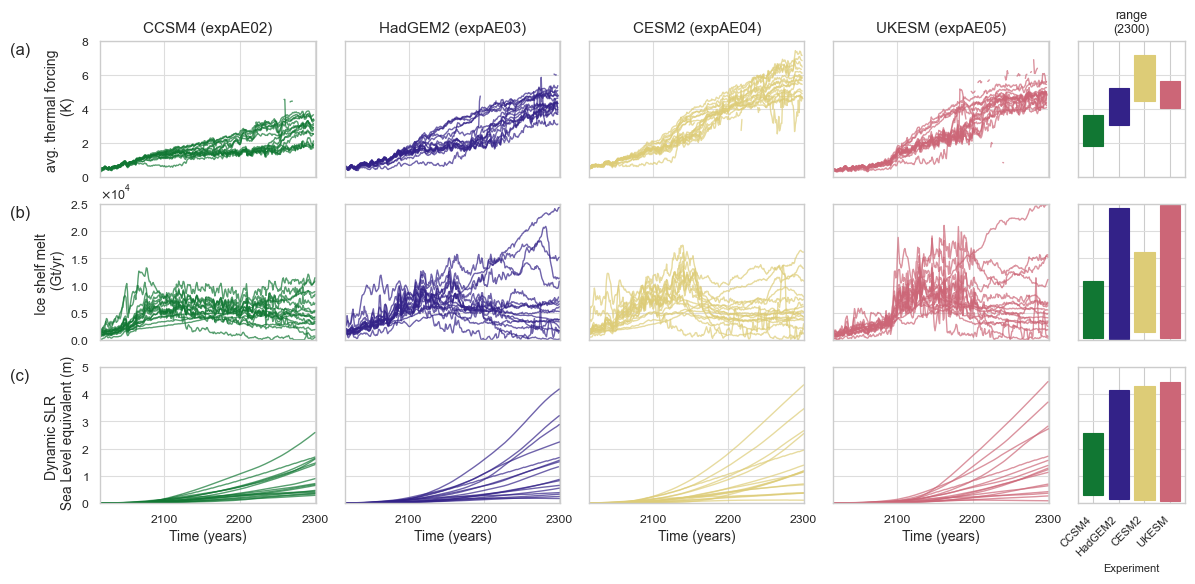

In [80]:
fig, axes = plt.subplots(
    3, 5, figsize=(14, 6),
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.5], 'wspace': 0.15}
)

panel_lines = [lines_forcing, lines_melt, lines_dslr]
panel_dicts = [valuesend_dict3, valuesend_dict, valuesend_dict2]
panel_ylabels = ['avg. thermal forcing \n (K)', 'Ice shelf melt \n (Gt/yr)',
                  'Dynamic SLR \n Sea Level equivalent (m)']
panel_ylims = [[0, 8], [0, 2.5 * 10**4], [0, 5]]
panels = ['(a)', '(b)', '(c)']

for row, (lines, vdict, ylabel, ylim) in enumerate(zip(panel_lines, panel_dicts, panel_ylabels, panel_ylims)):
    for iexp, expname in enumerate(expnames):
        ax = axes[row, iexp]
        exp_lines = [l for l in lines if l[0] == colors[iexp]]
        for color, x, y in exp_lines:
            ax.plot(x, y, linewidth=1, color=color, alpha=0.7)
        ax.set_axisbelow(True)
        ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
        ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
        ax.set_xlim([2015, 2301])
        ax.set_ylim(ylim)
        if row == 0:
            ax.set_title(f'{expnames_plot[iexp]} ({expnames[iexp]})', fontsize=11)
        if iexp == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        else:
            ax.tick_params(labelleft=False)
        if row < 2:
            ax.tick_params(labelbottom=False)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
        ax.yaxis.offsetText.set_fontsize(9)

    # --- comparison panel: same min-max (2300) range bars as the original figure,
    # now as their own compact subplot at the right of each row. x-axis is shared
    # down the column, tick labels only shown on the bottom row. ---
    ax_cmp = axes[row, 4]
    for iexp, expname in enumerate(expnames):
        x = [iexp - 0.4, iexp - 0.4, iexp + 0.4, iexp + 0.4]
        vals = vdict[expname]
        y = [np.nanmin(vals), np.nanmax(vals), np.nanmax(vals), np.nanmin(vals)]
        ax_cmp.fill(x, y, color=colors[iexp], edgecolor=colors[iexp])
    ax_cmp.set_xlim([-0.6, 3.6])
    ax_cmp.set_xticks(range(4))
    if row == 2:
        ax_cmp.set_xticklabels(expnames_plot, rotation=45, ha='right', fontsize=8)
    else:
        ax_cmp.tick_params(labelbottom=False)
    ax_cmp.set_ylim(ylim)
    ax_cmp.tick_params(labelleft=False)
    if row == 0:
        ax_cmp.set_title('range\n(2300)', fontsize=9)
    ax_cmp.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_cmp.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
    ax_cmp.grid(which='major', axis='y', color='#DDDDDD', linewidth=0.8)
    ax_cmp.set_axisbelow(True)

    axes[row, 0].text(-0.42, 0.9, panels[row], transform=axes[row, 0].transAxes, fontsize=12)

for iexp in range(4):
    axes[2, iexp].set_xlabel('Time (years)', fontsize=10)
axes[2, 4].set_xlabel('Experiment', fontsize=8)

plt.tight_layout()
fig.savefig('analysis/figs/paper/Intropic_by_forcing.jpeg', dpi=200, bbox_inches='tight')
fig.savefig('analysis/figs/paper/Intropic_by_forcing.pdf', bbox_inches='tight')
plt.show()

## 2c. Alternative version: add PICO's own thermal forcing for the whole AIS

Adds a new top row to the figure above, showing PICO's own reported thermal
forcing for the whole Antarctic Ice Sheet (`reviewing/TF_PICO_expt_0X.nc`,
variable `thermal_forcing_ais`), PICO's continental-shelf average over 400-800 m
depth, one line per climate-forcing experiment.

**Note:** this is PICO's raw/unprocessed TF. We still need to subtract the
$\Delta T$ correction PICO applies internally before this is directly
comparable to our own TF panel below it. For now this is just plotted as-is
for a first look.

Run cell 6 first (for the other three rows); this cell loads the PICO files
itself, so it does not depend on the external drive.

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_82077/2902555092.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


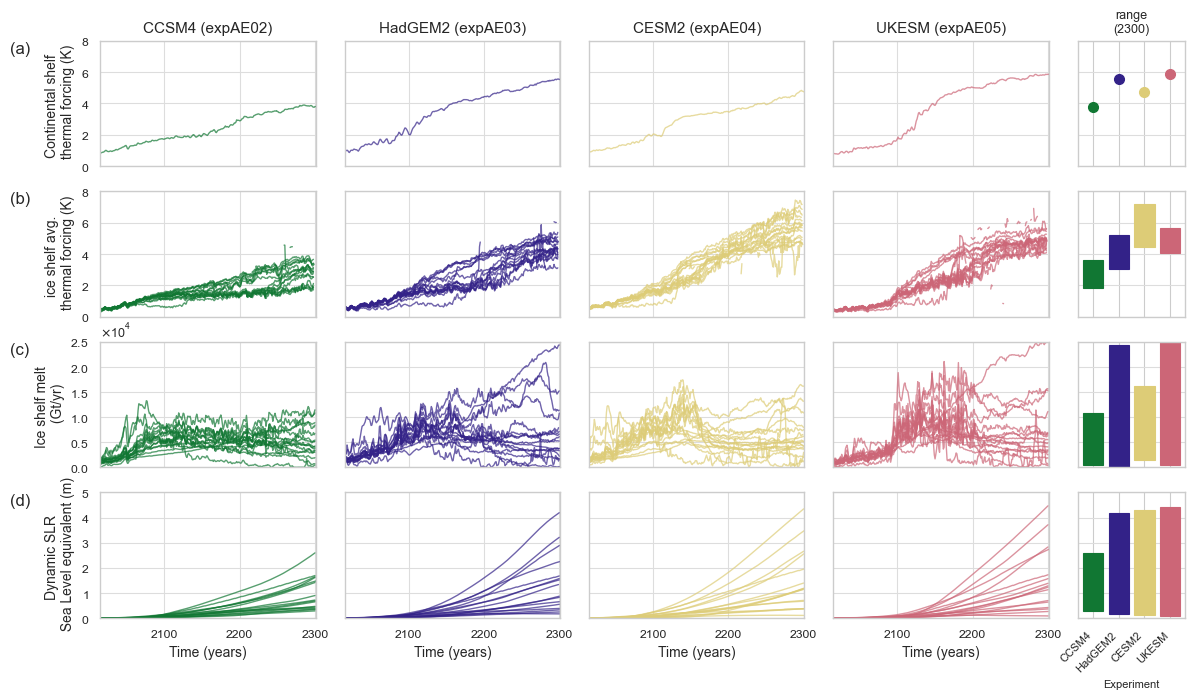

In [86]:
# --- PICO's own thermal forcing for the whole AIS (continental-shelf average,
# 400-800 m depth), one line per climate-forcing experiment. This is PICO's
# raw/unprocessed TF -- we still need to subtract the DT correction PICO
# applies internally before this is directly comparable to our own TF panel
# below. For now we just plot it as-is. ---
pico_lines = []
pico_end = {}
for iexp, expname in enumerate(expnames):
    exp_num = expname[-2:]
    d_pico = xr.open_dataset(f'reviewing/TF_PICO_expt_{exp_num}_withoutdeltaT.nc', decode_times=True)
    t_years = np.array([tt.year for tt in d_pico.time.values])
    y_pico = d_pico['thermal_forcing_ais'].values
    valid = ~np.isnan(y_pico)
    pico_lines.append((colors[iexp], t_years[valid], y_pico[valid]))
    pico_end[expname] = y_pico[valid][-1]
    d_pico.close()

fig, axes = plt.subplots(
    4, 5, figsize=(14, 7.5),
    gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.5], 'wspace': 0.15}
)

panel_lines = [pico_lines, lines_forcing, lines_melt, lines_dslr]
panel_dicts = [None, valuesend_dict3, valuesend_dict, valuesend_dict2]
panel_ylabels = ['Continental shelf \n thermal forcing (K)',
                  'ice shelf avg. \n thermal forcing (K)', 'Ice shelf melt \n (Gt/yr)',
                  'Dynamic SLR \n Sea Level equivalent (m)']
panel_ylims = [[0, 8], [0, 8], [0, 2.5 * 10**4], [0, 5]]
panels = ['(a)', '(b)', '(c)', '(d)']

for row, (lines, vdict, ylabel, ylim) in enumerate(zip(panel_lines, panel_dicts, panel_ylabels, panel_ylims)):
    for iexp, expname in enumerate(expnames):
        ax = axes[row, iexp]
        exp_lines = [l for l in lines if l[0] == colors[iexp]]
        for color, x, y in exp_lines:
            ax.plot(x, y, linewidth=1, color=color, alpha=0.7)
        ax.set_axisbelow(True)
        ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
        ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
        ax.set_xlim([2015, 2301])
        ax.set_ylim(ylim)
        if row == 0:
            ax.set_title(f'{expnames_plot[iexp]} ({expnames[iexp]})', fontsize=11)
        if iexp == 0:
            ax.set_ylabel(ylabel, fontsize=10)
        else:
            ax.tick_params(labelleft=False)
        if row < 3:
            ax.tick_params(labelbottom=False)
        ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
        ax.yaxis.offsetText.set_fontsize(9)

    # --- comparison panel (col 5): min-max range box for the ensemble rows,
    # a single point for the PICO row (one value per experiment, not an
    # ensemble, so there is no spread to show). ---
    ax_cmp = axes[row, 4]
    if vdict is None:
        for iexp, expname in enumerate(expnames):
            ax_cmp.plot(iexp, pico_end[expname], 'o', color=colors[iexp], markersize=7)
    else:
        for iexp, expname in enumerate(expnames):
            x = [iexp - 0.4, iexp - 0.4, iexp + 0.4, iexp + 0.4]
            vals = vdict[expname]
            y = [np.nanmin(vals), np.nanmax(vals), np.nanmax(vals), np.nanmin(vals)]
            ax_cmp.fill(x, y, color=colors[iexp], edgecolor=colors[iexp])
    ax_cmp.set_xlim([-0.6, 3.6])
    ax_cmp.set_xticks(range(4))
    if row == 3:
        ax_cmp.set_xticklabels(expnames_plot, rotation=45, ha='right', fontsize=8)
    else:
        ax_cmp.tick_params(labelbottom=False)
    ax_cmp.set_ylim(ylim)
    ax_cmp.tick_params(labelleft=False)
    if row == 0:
        ax_cmp.set_title('range\n(2300)', fontsize=9)
    ax_cmp.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax_cmp.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
    ax_cmp.grid(which='major', axis='y', color='#DDDDDD', linewidth=0.8)
    ax_cmp.set_axisbelow(True)

    axes[row, 0].text(-0.42, 0.9, panels[row], transform=axes[row, 0].transAxes, fontsize=12)

for iexp in range(4):
    axes[3, iexp].set_xlabel('Time (years)', fontsize=10)
axes[3, 4].set_xlabel('Experiment', fontsize=8)
# x
plt.tight_layout()
fig.savefig('analysis/figs/paper/Intropic_by_forcing_with_PICO.jpeg', dpi=200, bbox_inches='tight')
fig.savefig('analysis/figs/paper/Intropic_by_forcing_with_PICO.pdf', bbox_inches='tight')
plt.show()

## 2d. Continental-shelf thermal forcing by sector (all regions except AIS)

Same raw/unprocessed continental-shelf-averaged thermal forcing as in 2c, now
broken out by sector instead of whole-AIS: Amundsen, Ross, Filchner-Ronne,
Aurora, and Wilkes (all sectors used elsewhere in this analysis, except AIS
itself). One panel per sector, four lines per panel (one per climate-forcing
experiment). Loads the PICO files itself, so no external drive needed. Same
caveat as 2c: this is raw/unprocessed, the $\Delta T$ correction still needs
to be subtracted.

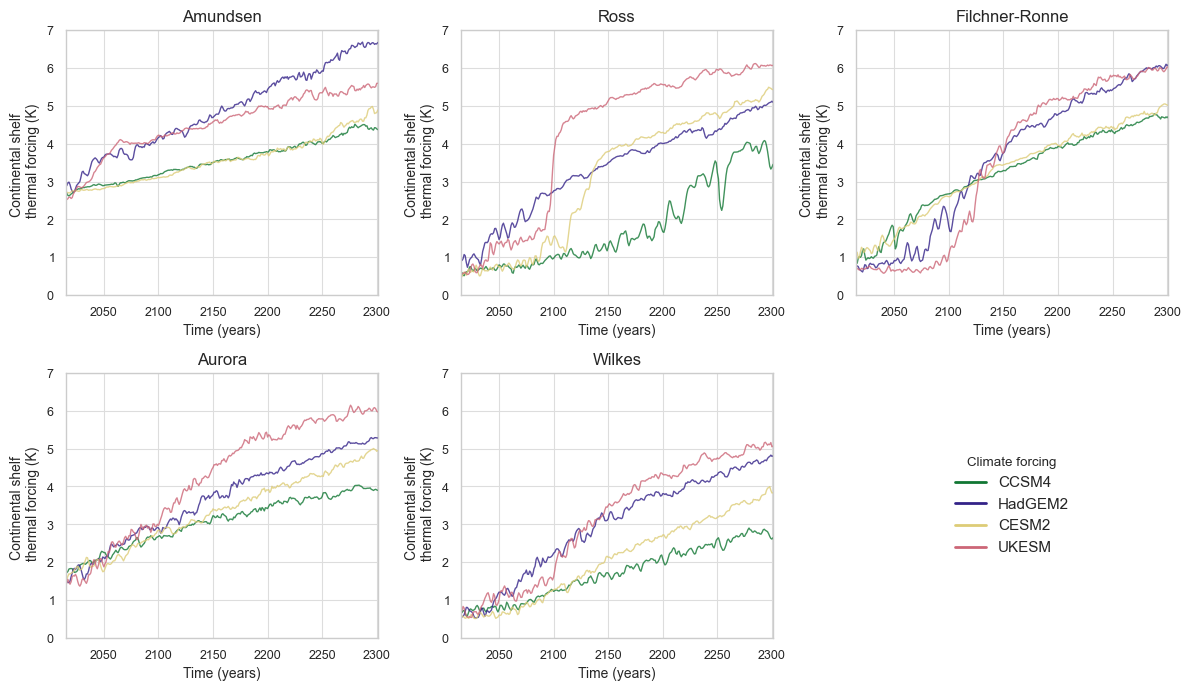

In [85]:
PICO_VAR = {
    'Amundsen': 'thermal_forcing_ase',
    'Ross': 'thermal_forcing_ross',
    'FilchnerRonne': 'thermal_forcing_fris',
    'Aurora': 'thermal_forcing_aurora',
    'Wilkes': 'thermal_forcing_wilkes',
}
regions_no_ais = list(PICO_VAR.keys())
DISPLAY_NAME = {'FilchnerRonne': 'Filchner-Ronne'}

# --- load once per experiment, keep all sectors from that file ---
pico_by_exp = {}
for expname in expnames:
    exp_num = expname[-2:]
    d_pico = xr.open_dataset(f'reviewing/TF_PICO_expt_{exp_num}_withoutdeltaT.nc', decode_times=True)
    t_years = np.array([tt.year for tt in d_pico.time.values])
    pico_by_exp[expname] = dict(time=t_years, **{r: d_pico[v].values for r, v in PICO_VAR.items()})
    d_pico.close()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes_flat = axes.flatten()

for ax, region in zip(axes_flat, regions_no_ais):
    for iexp, expname in enumerate(expnames):
        t = pico_by_exp[expname]['time']
        y = pico_by_exp[expname][region]
        valid = ~np.isnan(y)
        ax.plot(t[valid], y[valid], color=colors[iexp], linewidth=1, alpha=0.8)
    ax.set_title(DISPLAY_NAME.get(region, region), fontsize=12)
    ax.set_xlim([2015, 2301])
    ax.set_ylim([0, 7])
    ax.set_axisbelow(True)
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8)
    ax.grid(which='minor', color='#EEEEEE', linestyle=':', linewidth=0.5)
    ax.set_ylabel('Continental shelf \n thermal forcing (K)', fontsize=10)
    ax.set_xlabel('Time (years)', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="scientific", scilimits=(0, 0))
    ax.yaxis.offsetText.set_fontsize(8)

# 6th slot (2x3 grid, 5 regions): use for the shared legend instead of leaving it blank
axes_flat[-1].axis('off')
legend_lines = [mlines.Line2D([], [], color=colors[i], linewidth=2, label=expnames_plot[i]) for i in range(4)]
axes_flat[-1].legend(handles=legend_lines, loc='center', fontsize=11, frameon=False, title='Climate forcing')

plt.tight_layout()
fig.savefig('analysis/figs/paper/TF_shelf_by_sector.jpeg', dpi=200, bbox_inches='tight')
fig.savefig('analysis/figs/paper/TF_shelf_by_sector.pdf', bbox_inches='tight')
plt.show()

In [62]:
valuesend_dict

{'expAE02': [8032.9310208,
  10549.469397385215,
  3195.239040811008,
  3665.36132919296,
  724.742914965504,
  1849.362988662784,
  5102.459802353664,
  10925.335944101887,
  8794.102304866305,
  4089.236483473408,
  3368.214553690112,
  6503.453438246912,
  5178.360464408576,
  3009.09703725056,
  412.549023531008,
  4139.190442786816],
 'expAE03': [1699.711966773248,
  5965.827148873728,
  125.030390300672,
  15086.854311247873,
  9846.291982974975,
  3641.90141251584,
  3777.834711515136,
  11280.118496362496,
  24331.00905919283,
  5261.07455520768,
  1259.246427570176,
  6519.22080006144,
  7902.41501773824,
  7051.575017078784,
  3351.938238251008,
  2499.788809437184],
 'expAE04': [4303.322886438912,
  6521.72261851136,
  7379.755615649792,
  4348.12154281984,
  1977.648024649728,
  5115.387117043712,
  13193.470592155649,
  16162.511690661888,
  6111.109249499136,
  8122.868172849152,
  11020.406118940671,
  3614.567703773184,
  3966.211977117696,
  1383.777527922688,
  2128.6

###### 